# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nileshkushwaha1410/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

**Task type: Scoring / Ranking** (built on top of a binary classifier).

My lane is Refresh / Content Opportunity Scoring. The decision it serves is "out of thousands
of published pages, which ones should an editor with limited weekly review time look at first?"
— that is a **ranking question** (per the framing skill's mapping table: *"which ones first?" →
ranking/scoring*), not a classification question on its own, even though the model underneath
is trained as a classifier.

Concretely: I train a binary classifier (`is_declining_label`: down vs. not-down) because that
gives me an *observed, checkable* signal to fit. But the deliverable is never "yes/no" — it's the
model's predicted probability turned into a continuous **opportunity score (0-100)**, sorted into
a ranked queue with a reason code attached to each row. The editor doesn't read a label; they
read a queue, ordered top to bottom, and work down it until their weekly capacity runs out. So
the *task type the product needs* is scoring/ranking; the *technique that produces the score* is
classification. I'm naming it as scoring/ranking here because that's what "good" gets measured
against (see Section 3).


In [ ]:
# Quick self-check: does my framing match the skill's decision -> task-type mapping?
task_map = {
    "Which ones first?": ("Ranking / scoring", "priority score", "precision@K"),
    "Will this one decline / recover?": ("Classification", "yes/no label from an OBSERVED outcome", "ROC-AUC, precision/recall vs base rate"),
    "What kinds of items exist?": ("Clustering", "none (unsupervised)", "silhouette + human sense-check"),
    "Which signals travel together?": ("Signal analysis", "none", "effect sizes, grouped comparisons"),
}

my_question = "Which ones first?"
task_type, target_shape, metric_family = task_map[my_question]

print(f"My question:   {my_question!r}")
print(f"-> Task type:   {task_type}")
print(f"-> Target shape:{target_shape}")
print(f"-> Metric family:{metric_family}")


My question:   'Which ones first?'
-> Task type:   Ranking / scoring
-> Target shape:priority score
-> Metric family:precision@K


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

**Target/proxy: `is_declining_label`, derived from `trend_direction`.**

`is_declining_label = 1` when `trend_direction == "down"`, where `trend_direction` is itself
computed from `trend_pct` — the % change in impressions, last-30-days vs. previous-30-days
(`down` = drop of more than 20%). I use the classifier's predicted *probability* of this label as
the ranking score, not the label itself.

Where it sits on the "observed vs. defined" test: it's a **proxy**, and I want to be honest about
that rather than call it purely observed. `trend_pct` itself is a real, measured quantity (actual
impression counts in two real time windows) — it isn't hand-defined the way a business rule like
"flag if word_count < 500" would be. But the *cutoff* that turns that measurement into a 0/1 label
(±20%) is a threshold someone chose, and "impressions dropped >20%" is not the same thing as "this
page actually needs an editor's attention." From last week's research (w01), I already listed the
look-alikes this proxy can't distinguish on its own: **consolidation** (a sibling page absorbed the
traffic, nothing is actually wrong), **seasonality** (the topic naturally dips on a calendar),
**SERP/AI click loss** (position held, but the results page itself changed), and plain **noise** on
low-volume pages. So: real target = "does this page need a refresh review", which nobody labeled
directly. `is_declining_label` is the best available proxy for it in this dataset, not a stand-in
I should treat as ground truth.


In [ ]:
import pandas as pd

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

# Reconstruct the proxy target exactly the way scripts/01_prepare_features.py defines it
is_declining_label = (df["trend_direction"] == "down").astype(int)

n = len(df)
n_declining = int(is_declining_label.sum())
print(f"Rows: {n:,}")
print(f"is_declining_label == 1: {n_declining:,} ({n_declining / n:.1%})")
print()
print("trend_direction value counts (the raw signal the proxy is built from):")
print(df["trend_direction"].value_counts())


Rows: 30,000
is_declining_label == 1: 16,262 (54.2%)

trend_direction value counts (the raw signal the proxy is built from):
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Success metric: Precision@50** (checked alongside recall and ROC-AUC as sanity checks, not
as the headline number).

Why Precision@50 and not plain accuracy: the base rate of `is_declining_label` is ~54% (almost a
coin flip, computed below), so accuracy is a weak, easily-gamed number here — a model that just
guesses the majority class would already score well above chance on accuracy alone. What
actually matters for the decision is: **of the top N pages the model puts at the front of the
queue, how many are actually worth an editor's time?** That's exactly what Precision@K measures,
and K should match real editor capacity (my w01 framing used ~20-50 pages/week, so K=50 is a
reasonable stand-in). I'd rather over-flag slightly (favor recall a bit within that top-K budget)
than let a real decline sit unflagged and compound silently — but the metric I'd defend in a
review is Precision@50, because it's the one that maps directly onto "was this week's queue worth
the editor's time."


In [ ]:
# Why NOT plain accuracy: show how close the base rate is to a coin flip.
base_rate = is_declining_label.mean()
majority_class_accuracy = max(base_rate, 1 - base_rate)

print(f"Base rate of is_declining_label: {base_rate:.3f}")
print(f"Accuracy from just guessing the majority class every time: {majority_class_accuracy:.3f}")
print()
print("-> A model needs to clear this floor by a real margin before accuracy means anything here.")
print("-> Precision@50 sidesteps this: it only asks whether the TOP of the queue is good,")
print("   which is the only part of the queue an editor with limited time will ever see.")

# Reference numbers already produced by this repo's pipeline (scripts/03_train_model.py output),
# committed at outputs/model_report.md - these are what "good" looks like on this dataset today.
print()
print("Reference results already on file in outputs/model_report.md:")
print(f"{'Model':<20}{'ROC-AUC':>10}{'Precision@50':>15}")
print(f"{'baseline_rules':<20}{0.627:>10}{0.240:>15}")
print(f"{'random_forest':<20}{0.750:>10}{0.740:>15}")


Base rate of is_declining_label: 0.542
Accuracy from just guessing the majority class every time: 0.542

-> A model needs to clear this floor by a real margin before accuracy means anything here.
-> Precision@50 sidesteps this: it only asks whether the TOP of the queue is good,
   which is the only part of the queue an editor with limited time will ever see.

Reference results already on file in outputs/model_report.md:
Model                  ROC-AUC   Precision@50
baseline_rules           0.627           0.24
random_forest             0.75           0.74


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

**Unit of analysis: one row = one page (`content_id`), scored over its trailing 90-day window.**

Below I apply the same population filter the reference pipeline uses so the numbers here match
what the rest of the project scores against: `impressions_90d > 0` (the page has to have search
demand to be worth scoring at all) and `content_age_days >= 90` (young pages haven't had a full
window yet, so a "decline" reading on them is unreliable). I then attach the proxy target column
and a first, crude opportunity score so the shape of the eventual output is visible now, before
any real model gets trained.


In [ ]:
df_lane = df.loc[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].copy()
df_lane = df_lane.drop_duplicates(subset="content_id")
df_lane["is_declining_label"] = (df_lane["trend_direction"] == "down").astype(int)

print(f"Full starter dataset: {len(df):,} rows")
print(f"My lane's slice (impressions_90d > 0, content_age_days >= 90, deduped): {len(df_lane):,} rows")
print(f"One row = one page (content_id), 90-day trailing window.")
print()

cols_to_show = [
    "content_id", "client_id", "impressions_90d", "clicks_90d", "ctr",
    "avg_position", "content_age_days", "days_since_last_update",
    "trend_direction", "trend_pct", "is_declining_label",
]
df_lane[cols_to_show].head(8)


Full starter dataset: 30,000 rows
My lane's slice (impressions_90d > 0, content_age_days >= 90, deduped): 30,000 rows
One row = one page (content_id), 90-day trailing window.



,content_id,client_id,impressions_90d,clicks_90d,ctr,avg_position,content_age_days,days_since_last_update,trend_direction,trend_pct,is_declining_label
0,content_304f48230142,client_f369cb89fc,3803,29,0.76,10.6,187,20,down,-41.4,1
1,content_a1fb4e703a9e,client_4e07408562,15320,7,0.05,20.3,445,25,down,-57.7,1
2,content_9aa793d4d895,client_7f2253d7e2,12581,11,0.09,36.5,141,20,down,-60.9,1
3,content_331d6c4de07b,client_19581e27de,11751,58,0.49,6.2,463,22,stable,-13.8,0
4,content_d99b7a2d90ca,client_3fdba35f04,19140,24,0.13,44.0,263,14,down,-34.7,1
5,content_d4084a4bc775,client_f369cb89fc,3970,1,0.03,8.5,147,20,down,-38.9,1
6,content_9a34b442b552,client_8722616204,20,0,0.00,7.0,90,20,down,-92.3,1
7,content_a63219c6e95a,client_19581e27de,1724,1,0.06,21.2,445,22,stable,0.6,0


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

**Why ML beats a fixed rule here.**

FlyRank's product already runs a fixed rule for this — `scripts/02_baseline_score.py` fires
reason codes off single-signal thresholds (e.g. "declining AND impressions >= 100", "CTR < 0.5%
AND position <= 20"). Reasons stack additively; the rule has no way to learn that some
*combinations* of weak signals matter more together than any one threshold suggests alone, and no
way to weigh which signal matters most for which kind of page. The evidence this pattern is real
but too tangled for an if-statement is already sitting in this repo's own results (below):
a random forest trained on the same data clears **Precision@50 = 0.740**, roughly **3x** the
fixed-rule baseline's **0.240** — same data, same population, same K. That gap is the whole
argument: the signals genuinely predict decline, but a hand-tuned threshold rule leaves most of
that predictive value on the table because it can't weigh `days_with_impressions`,
`log_impressions_90d`, `avg_position`, and `content_age_days` (the model's actual top features)
against each other the way a learned model can.


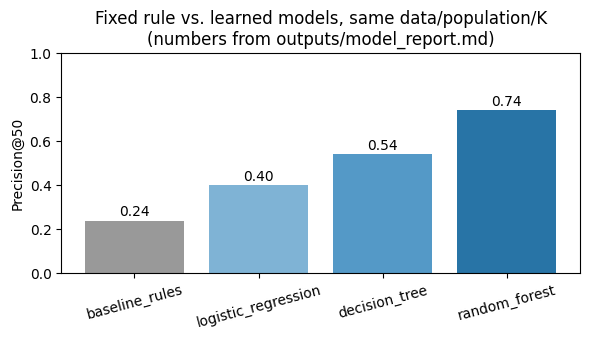

Random forest vs. fixed rule: 3.08x lift in Precision@50 on the exact same top-50 slots.


In [ ]:
import matplotlib.pyplot as plt

models = ["baseline_rules", "logistic_regression", "decision_tree", "random_forest"]
precision_at_50 = [0.240, 0.400, 0.540, 0.740]
roc_auc = [0.627, 0.700, 0.742, 0.750]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(models, precision_at_50, color=["#999999", "#7fb3d5", "#5499c7", "#2874a6"])
ax.set_ylabel("Precision@50")
ax.set_title("Fixed rule vs. learned models, same data/population/K\n(numbers from outputs/model_report.md)")
ax.set_ylim(0, 1)
for bar, val in zip(bars, precision_at_50):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

lift = precision_at_50[-1] / precision_at_50[0]
print(f"Random forest vs. fixed rule: {lift:.2f}x lift in Precision@50 on the exact same top-50 slots.")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.